# Data Cleaning & Preprocessing - BMW Pricing

End-to-end preparation of a BMW used-car dataset for price modeling: cleaning, outlier removal, null imputation, encoding, scaling and feature selection.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OrdinalEncoder

### 1. Data Structure

We begin by loading the dataset and inspecting it: its shape, column data types, summary statistics, and the number of missing values per column. This first look tells us what needs cleaning.

In [13]:
df_bmw = pd.read_csv(r'D:\GithubProjects\EDAbmwPricePrediction\bmw_pricing_original.csv')

# Rename columns to English for consistency across the project
df_bmw = df_bmw.rename(columns={
    'marca': 'make', 'modelo': 'model', 'potencia': 'power',
    'fecha_registro': 'registration_date', 'tipo_gasolina': 'fuel_type',
    'tipo_coche': 'car_type', 'volante_regulable': 'adjustable_steering',
    'aire_acondicionado': 'air_conditioning', 'camara_trasera': 'rear_camera',
    'asientos_traseros_plegables': 'folding_rear_seats',
    'elevalunas_electrico': 'electric_windows',
    'alerta_lim_velocidad': 'speed_limit_alert', 'precio': 'price',
    'fecha_venta': 'sale_date',
})

In [14]:
df_bmw.head()

,make,model,km,power,registration_date,fuel_type,color,car_type,adjustable_steering,air_conditioning,rear_camera,folding_rear_seats,electric_windows,bluetooth,gps,speed_limit_alert,price,sale_date
0,NaN,118,140411.0,100.0,2012-02-01,diesel,black,NaN,True,True,False,NaN,True,NaN,True,NaN,11300.0,2018-01-01
1,BMW,M4,13929.0,317.0,NaN,petrol,grey,convertible,True,True,False,NaN,False,True,True,True,69700.0,2018-02-01
2,BMW,320,183297.0,120.0,2012-04-01,diesel,white,NaN,False,False,False,NaN,True,False,True,False,10200.0,2018-02-01
3,BMW,420,128035.0,135.0,NaN,diesel,red,convertible,True,True,False,NaN,True,True,True,NaN,25100.0,2018-02-01
4,BMW,425,97097.0,160.0,NaN,diesel,silver,NaN,True,True,False,False,False,True,True,True,33400.0,2018-04-01


In [15]:
df_bmw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   make                 3873 non-null   object 
 1   model                4840 non-null   object 
 2   km                   4841 non-null   float64
 3   power                4842 non-null   float64
 4   registration_date    2420 non-null   object 
 5   fuel_type            4838 non-null   object 
 6   color                4398 non-null   object 
 7   car_type             3383 non-null   object 
 8   adjustable_steering  4839 non-null   object 
 9   air_conditioning     4357 non-null   object 
 10  rear_camera          4841 non-null   object 
 11  folding_rear_seats   1452 non-null   object 
 12  electric_windows     4841 non-null   object 
 13  bluetooth            4115 non-null   object 
 14  gps                  4843 non-null   bool   
 15  speed_limit_alert    4115 non-null   o

In [16]:
df_bmw.describe(include='all')

,make,model,km,power,registration_date,fuel_type,color,car_type,adjustable_steering,air_conditioning,rear_camera,folding_rear_seats,electric_windows,bluetooth,gps,speed_limit_alert,price,sale_date
count,3873,4840,4.841000e+03,4842.000000,2420,4838,4398,3383,4839,4357,4841,1452,4841,4115,4843,4115,4837.000000,4842
unique,1,76,NaN,NaN,180,5,10,8,2,2,2,2,2,2,2,2,NaN,13
top,BMW,320,NaN,NaN,2013-07-01,diesel,black,estate,True,True,False,False,False,False,True,True,NaN,2018-05-01
freq,3873,752,NaN,NaN,93,4631,1499,1107,2662,3465,3864,1150,2612,3119,4514,2240,NaN,809
mean,NaN,NaN,1.409593e+05,128.981826,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15831.920612,NaN
std,NaN,NaN,6.020853e+04,38.994839,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9222.630708,NaN
min,NaN,NaN,-6.400000e+01,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,NaN
25%,NaN,NaN,1.028840e+05,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10800.000000,NaN
50%,NaN,NaN,1.410800e+05,120.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14200.000000,NaN
75%,NaN,NaN,1.752170e+05,135.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18600.000000,NaN


In [17]:
df_bmw.shape

(4843, 18)

In [18]:
df_bmw.isnull().sum()

make                    970
model                     3
km                        2
power                     1
registration_date      2423
fuel_type                 5
color                   445
car_type               1460
adjustable_steering       4
air_conditioning        486
rear_camera               2
folding_rear_seats     3391
electric_windows          2
bluetooth               728
gps                       0
speed_limit_alert       728
price                     6
sale_date                 1
dtype: int64

### 2. Data Cleaning
* Delete duplicate records
* Delete rows without target reported
* Remove irrelevant columns
* Correct literal mistakes
* Correct data types
* Remove outliers

We start with basic integrity checks. Are there duplicate rows? Are there records with no `price`? Since `price` is the target we want to predict, rows without it cannot be used and are removed.

In [19]:
# Check for duplicate records
df_bmw.duplicated().sum()

np.int64(0)

In [20]:
# Check records with no target (price) reported
df_bmw['price'].isnull().sum()

np.int64(6)

In [21]:
# Drop records with no target reported
df_bmw.dropna(subset='price', inplace=True)

Next we drop columns that carry no useful signal: `make` (constant — every car is a BMW) and `folding_rear_seats` (mostly missing).

In [22]:
# Drop the 'make' column (constant: all rows are BMW)
del df_bmw['make']

In [23]:
# Drop 'folding_rear_seats': its share of null values is very high
del df_bmw['folding_rear_seats']

Inspecting each column's unique values surfaces a few literal errors — for example `Diesel` vs `diesel`, and a stray `' True'` with a leading space in `gps`. We standardize these values and group the rarest fuel types into a single `other` category.

In [24]:
# Inspect unique values to find literal (typo) mistakes
for col in df_bmw:
    print(col, df_bmw[col].unique(), '\n')

model ['118' 'M4' '320' '420' '425' '335' '325' 'Z4' '120' '220' '650' '135'
 '218' '318' '430' 'M3' '330' '225' 'M235' '316' '435' '640'
 '640 Gran Coupé' '435 Gran Coupé' 'i8' '630' '430 Gran Coupé' '635' '520'
 nan '525' '530' '535' '320 Gran Turismo' '518' '116' '328' '523' 'X3'
 'M550' '528' '325 Gran Turismo' '125' '318 Gran Turismo' '420 Gran Coupé'
 'i3' '114' '520 Gran Turismo' '530 Gran Turismo' 'M135' '418 Gran Coupé'
 '330 Gran Turismo' '335 Gran Turismo' '730' '123' '535 Gran Turismo'
 '740' '750' 'ActiveHybrid 5' '735' 'M5' 'X5' 'X1' 'X4' 'X6' 'X6 M' 'X5 M'
 'X5 M50' '218 Active Tourer' '218 Gran Tourer' '216' '220 Active Tourer'
 '216 Gran Tourer' '216 Active Tourer' ' Active Tourer'
 '225 Active Tourer' '214 Gran Tourer'] 

km [140411.  13929. 183297. ...  19633.  27920. 195840.] 

power [100. 317. 120. 135. 160. 225. 145. 105. 125. 130. 270. 110. 140. 180.
  85. 190. 236. 240. 250. 230. 309. 170. 142. 155. 210.  nan 122. 200.
  90. 150. 141. 173. 137. 280. 112. 189.  8

In [25]:
# Unify 'Diesel' and 'diesel' into a single category
df_bmw['fuel_type'] = df_bmw['fuel_type'].replace('Diesel', 'diesel')

# Group hybrid-petrol and electric cars into a single 'other' category
df_bmw['fuel_type'] = df_bmw['fuel_type'].replace('hybrid_petrol', 'other')
df_bmw['fuel_type'] = df_bmw['fuel_type'].replace('electro', 'other')

In [26]:
# Fix the gps records where the value is ' True' (with a leading space)
df_bmw['gps'] = df_bmw['gps'].replace(' True', 'True')

# Cast gps from bool to object to unify it with the other columns
df_bmw['gps'] = df_bmw['gps'].astype('object')

The `model` column has a long tail of infrequent models. To avoid dozens of sparse categories later on, we group every model representing less than 1% of the records into an `other` bucket.

In [27]:
# Group car models with less than 1% of the records

# Count of each car model
model_counts = df_bmw['model'].value_counts()

# Total number of cars
total_cars = df_bmw.shape[0]

# Percentage of cars for each model
percentages = model_counts / total_cars * 100

# DataFrame with models, counts and percentages
model_counts_percent = pd.DataFrame({'model': model_counts.index, 'count': model_counts, 'percentage': percentages})

# Cumulative percentage
model_counts_percent['acc_percentage'] = model_counts_percent['percentage'].cumsum()

In [28]:
def group_models(df, model_column, threshold=0.01):
    """
    Group the models with less than 1% of associated records in the 'model' column.
    """
    # Count records per model (as a proportion)
    model_counts = df[model_column].value_counts(normalize=True)

    # Identify models with less than 1% of the records
    low_count_models = model_counts[model_counts < threshold].index

    # Overwrite rare models with 'other'
    df[model_column] = df[model_column].apply(lambda x: 'other' if x in low_count_models else x)

    return df

In [29]:
df_bmw = group_models(df_bmw, 'model')
df_bmw['model'].unique()

array(['118', 'other', '320', '318', '316', '520', nan, '525', '530',
       '320 Gran Turismo', '518', '116', 'X3', '318 Gran Turismo', 'X5',
       'X1'], dtype=object)

In [30]:
df_bmw['model'].value_counts()

model
320                 750
520                 632
other               630
318                 567
X3                  438
116                 358
X1                  274
316                 234
X5                  231
525                 184
530                 157
118                 143
318 Gran Turismo     97
320 Gran Turismo     73
518                  66
Name: count, dtype: int64

Finally, we parse the date columns into datetime and engineer age-related features: the registration and sale years, and `days_owned` (how long the car was held before sale). Once those are extracted, the raw date columns are no longer needed.

In [31]:
# Convert the date columns from object to datetime
df_bmw['registration_date'] = pd.to_datetime(df_bmw['registration_date'])
df_bmw['sale_date'] = pd.to_datetime(df_bmw['sale_date'])

In [32]:
# Extract the sale and registration years,
# and create 'days_owned' to capture the age of the car at sale time.
df_bmw['sale_year'] = df_bmw['sale_date'].dt.year
df_bmw['registration_year'] = df_bmw['registration_date'].dt.year
df_bmw['days_owned'] = (df_bmw['sale_date'] - df_bmw['registration_date']).dt.days

In [33]:
df_bmw['sale_year'].value_counts()

sale_year
2018.0    4832
2007.0       1
2010.0       1
2009.0       1
2008.0       1
Name: count, dtype: int64

In [34]:
# We can now drop 'registration_date', 'sale_date' and 'sale_year'
# (the sale year is 2018 for almost all cars, so it carries no signal)
del df_bmw['registration_date']
del df_bmw['sale_date']
del df_bmw['sale_year']

In [35]:
# Check data types
df_bmw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4837 entries, 0 to 4842
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model                4834 non-null   object 
 1   km                   4835 non-null   float64
 2   power                4836 non-null   float64
 3   fuel_type            4832 non-null   object 
 4   color                4393 non-null   object 
 5   car_type             3379 non-null   object 
 6   adjustable_steering  4833 non-null   object 
 7   air_conditioning     4352 non-null   object 
 8   rear_camera          4835 non-null   object 
 9   electric_windows     4835 non-null   object 
 10  bluetooth            4109 non-null   object 
 11  gps                  4837 non-null   object 
 12  speed_limit_alert    4109 non-null   object 
 13  price                4837 non-null   float64
 14  registration_year    2419 non-null   float64
 15  days_owned           2419 non-null   float6

### 3. EDA: Variable distribution

To treat each variable appropriately, we split them by type — numeric, boolean, and categorical — and review their distributions with histograms, box plots, and value counts. Price turns out to be clearly right-skewed.

In [36]:
target = ['price']

def get_variable_lists(dataset):
    numeric_vars = []
    boolean_vars = []
    categorical_vars = []

    for col in dataset:
        if (dataset[col].dtype.kind in ("f", "i")) and len(dataset[col].unique()) != 2 and col not in target:
            numeric_vars.append(col)
        elif (dataset[col].dtype.kind in ("f", "i", "O")) and (len(dataset[col].dropna().unique()) == 2) and col not in target:
            boolean_vars.append(col)
        elif (dataset[col].dtype.kind == "O") and col not in target:
            categorical_vars.append(col)
    return numeric_vars, boolean_vars, categorical_vars

In [37]:
numeric_vars, boolean_vars, categorical_vars = get_variable_lists(df_bmw)
numeric_vars, boolean_vars, categorical_vars

(['km', 'power', 'registration_year', 'days_owned'],
 ['adjustable_steering',
  'air_conditioning',
  'rear_camera',
  'electric_windows',
  'bluetooth',
  'gps',
  'speed_limit_alert'],
 ['model', 'fuel_type', 'color', 'car_type'])

In [38]:
print(len(df_bmw.columns), "total number of variables")
print(len(target), "variable to predict")
print(len(categorical_vars), "categorical variables")
print(len(boolean_vars), "boolean variables")
print(len(numeric_vars), "numeric variables")

16 total number of variables
1 variable to predict
4 categorical variables
7 boolean variables
4 numeric variables


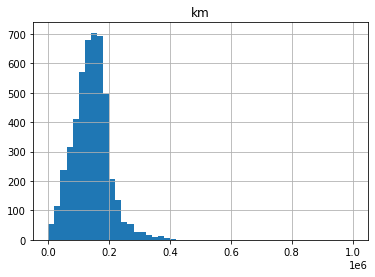

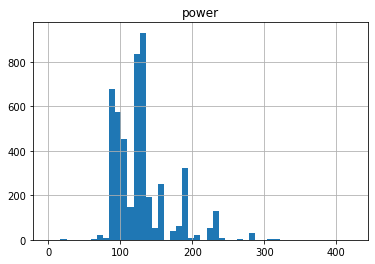

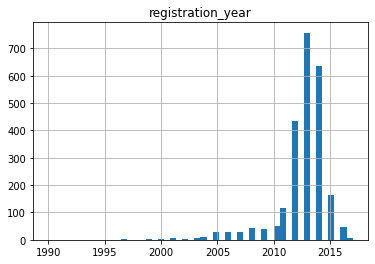

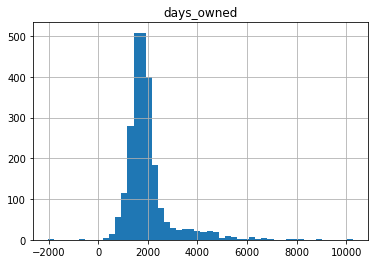

In [39]:
# Distribution of the numeric variables
for col in numeric_vars:
    df_bmw.hist(col, bins=50)

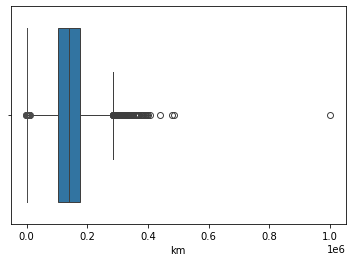

In [40]:
for col in numeric_vars:
    sns.boxplot(x=col, data=df_bmw)

In [41]:
# Distribution of the categorical variables
for col in categorical_vars:
    print(df_bmw[col].value_counts())

model
320                 750
520                 632
other               630
318                 567
X3                  438
116                 358
X1                  274
316                 234
X5                  231
525                 184
530                 157
118                 143
318 Gran Turismo     97
320 Gran Turismo     73
518                  66
Name: count, dtype: int64
fuel_type
diesel    4630
petrol     191
other       11
Name: count, dtype: int64
color
black     1498
grey      1069
blue       644
white      484
brown      302
silver     292
red         47
beige       37
green       14
orange       6
Name: count, dtype: int64
car_type
estate         1104
sedan           821
suv             755
hatchback       488
subcompact       77
coupe            75
convertible      30
van              29
Name: count, dtype: int64


### 4. Remove outliers and Impute null values

In [42]:
df_bmw.describe()

,km,power,price,registration_year,days_owned
count,4.835000e+03,4836.000000,4837.000000,2419.000000,2419.000000
mean,1.409664e+05,128.995037,15831.920612,2012.507234,1967.236875
std,6.022079e+04,39.011169,9222.630708,2.497859,923.034732
min,-6.400000e+01,0.000000,100.000000,1990.000000,-2009.000000
25%,1.028700e+05,100.000000,10800.000000,2012.000000,1489.000000
50%,1.410680e+05,120.000000,14200.000000,2013.000000,1767.000000
75%,1.752435e+05,135.000000,18600.000000,2014.000000,2130.000000
max,1.000376e+06,423.000000,178500.000000,2017.000000,10258.000000


#### 4.1 Remove outliers

Guided by the summary statistics above, we drop physically implausible records: impossible mileage, near-zero power, extreme prices, and negative ownership durations.

In [43]:
# Remove records where km < 0 or km >= 400000
df_bmw.drop(df_bmw[(df_bmw['km'] < 0) | (df_bmw['km'] > 400000)].index, inplace=True)

In [44]:
# Remove records where power <= 50
df_bmw.drop(df_bmw[df_bmw['power'] <= 50].index, inplace=True)

In [45]:
# Remove records where price < 500 or price > 70000
df_bmw.drop(df_bmw[(df_bmw['price'] < 500) | (df_bmw['price'] > 70000)].index, inplace=True)

In [46]:
# Check records where days_owned < 0
df_bmw[df_bmw['days_owned'] < 0]

,model,km,power,fuel_type,color,car_type,adjustable_steering,air_conditioning,rear_camera,electric_windows,bluetooth,gps,speed_limit_alert,price,registration_year,days_owned
100,320,342768.0,135.0,diesel,black,NaN,False,True,False,True,False,True,NaN,8200.0,2011.0,-609.0
256,316,201102.0,85.0,diesel,black,estate,True,NaN,False,False,False,True,False,8800.0,2013.0,-2009.0


In [47]:
df_bmw.drop(df_bmw[df_bmw['days_owned'] < 0].index, inplace=True)

#### 4.2 Impute null values

In [48]:
df_bmw.isnull().sum()

model                     3
km                        2
power                     1
fuel_type                 4
color                   441
car_type               1450
adjustable_steering       4
air_conditioning        479
rear_camera               2
electric_windows          2
bluetooth               722
gps                       0
speed_limit_alert       721
price                     0
registration_year      2408
days_owned             2408
dtype: int64

For the remaining missing values, columns where nulls are negligible (< 1% of rows) simply have those rows dropped; the rest are imputed column by column below.

In [49]:
# Null-value summary
nulls = df_bmw.isnull().sum()
not_nulls = df_bmw.count()
summary = pd.DataFrame({
    'Not Nulls': not_nulls,
    'Nulls': nulls,
    'Total': not_nulls + nulls
})
summary['% Nulls'] = (summary['Nulls'] / summary['Total']) * 100
summary = summary[['Not Nulls', 'Nulls', 'Total', '% Nulls']]

summary

,Not Nulls,Nulls,Total,% Nulls
model,4803,3,4806,0.062422
km,4804,2,4806,0.041615
power,4805,1,4806,0.020807
fuel_type,4802,4,4806,0.083229
color,4365,441,4806,9.176030
car_type,3356,1450,4806,30.170620
adjustable_steering,4802,4,4806,0.083229
air_conditioning,4327,479,4806,9.966708
rear_camera,4804,2,4806,0.041615
electric_windows,4804,2,4806,0.041615


In [50]:
# Drop rows for columns whose share of nulls is below 1%
pct_threshold = 1
cols_below_threshold = summary[summary['% Nulls'] < pct_threshold].index
df_bmw = df_bmw.dropna(subset=cols_below_threshold)

In [51]:
df_bmw.isnull().sum()

model                     0
km                        0
power                     0
fuel_type                 0
color                   439
car_type               1442
adjustable_steering       0
air_conditioning        477
rear_camera               0
electric_windows          0
bluetooth               719
gps                       0
speed_limit_alert       718
price                     0
registration_year      2400
days_owned             2400
dtype: int64

In [52]:
# Impute color with the mode
df_bmw['color'] = df_bmw['color'].fillna(df_bmw['color'].mode()[0])

In [53]:
df_bmw['color'].value_counts()

color
black     1918
grey      1062
blue       636
white      479
brown      302
silver     288
red         46
beige       37
green       14
orange       6
Name: count, dtype: int64

For the equipment flags and `car_type`, we impute the mode **within each car model** rather than a single global mode. What is typical for an SUV differs from a compact, so this respects each model's own norm.

In [54]:
# Impute car_type with the mode, per car model
# Mode of car_type for each model
mode_by_model = df_bmw.groupby('model')['car_type'].apply(lambda x: x.mode().iloc[0])

# Fill nulls in 'car_type' with the mode for the corresponding model
for model, mode in mode_by_model.items():
    null_idx = df_bmw[(df_bmw['model'] == model) & (df_bmw['car_type'].isnull())].index
    df_bmw.loc[null_idx, 'car_type'] = mode

# Confirm there are no more nulls in 'car_type'
print(df_bmw['car_type'].isnull().sum())

0


In [55]:
# Impute air_conditioning with the mode, per car model
mode_by_model = df_bmw.groupby('model')['air_conditioning'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else None)

df_bmw['air_conditioning'] = df_bmw['air_conditioning'].fillna(mode_by_model)

print(df_bmw['air_conditioning'].isnull().sum())

0


C:\TEMP/ipykernel_16056/2174085194.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_bmw['air_conditioning'] = df_bmw['air_conditioning'].fillna(mode_by_model)


In [56]:
# Impute bluetooth with the mode, per car model
mode_by_model = df_bmw.groupby('model')['bluetooth'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else None)

df_bmw['bluetooth'] = df_bmw['bluetooth'].fillna(mode_by_model)

print(df_bmw['bluetooth'].isnull().sum())

0


C:\TEMP/ipykernel_16056/3917895495.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_bmw['bluetooth'] = df_bmw['bluetooth'].fillna(mode_by_model)


In [57]:
# Impute speed_limit_alert with the mode, per car model
mode_by_model = df_bmw.groupby('model')['speed_limit_alert'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else None)

df_bmw['speed_limit_alert'] = df_bmw['speed_limit_alert'].fillna(mode_by_model)

print(df_bmw['speed_limit_alert'].isnull().sum())

0


C:\TEMP/ipykernel_16056/4263094580.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_bmw['speed_limit_alert'] = df_bmw['speed_limit_alert'].fillna(mode_by_model)


In [58]:
df_bmw['days_owned'] = df_bmw['days_owned'].fillna(df_bmw['days_owned'].mean())

In [59]:
df_bmw['registration_year'] = df_bmw['registration_year'].fillna(df_bmw['registration_year'].mean())

In [60]:
df_bmw.isnull().sum()

model                  0
km                     0
power                  0
fuel_type              0
color                  0
car_type               0
adjustable_steering    0
air_conditioning       0
rear_camera            0
electric_windows       0
bluetooth              0
gps                    0
speed_limit_alert      0
price                  0
registration_year      0
days_owned             0
dtype: int64

In [61]:
# Once all nulls are filled, convert the str True/False values to 0/1
def bool_to_int(df, columns):
    for col in columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype(bool).astype(int)
    return df

In [62]:
df_bmw = bool_to_int(df_bmw, ['adjustable_steering', 'air_conditioning', 'rear_camera', 'electric_windows', 'bluetooth', 'gps', 'speed_limit_alert'])

In [63]:
df_bmw.head()

,model,km,power,fuel_type,color,car_type,adjustable_steering,air_conditioning,rear_camera,electric_windows,bluetooth,gps,speed_limit_alert,price,registration_year,days_owned
0,118,140411.0,100.0,diesel,black,hatchback,1,1,0,1,0,1,0,11300.0,2012.000000,2161.000000
1,other,13929.0,317.0,petrol,grey,convertible,1,1,0,0,1,1,1,69700.0,2012.546482,1955.726968
2,320,183297.0,120.0,diesel,white,estate,0,0,0,1,0,1,0,10200.0,2012.000000,2132.000000
3,other,128035.0,135.0,diesel,red,convertible,1,1,0,1,1,1,1,25100.0,2012.546482,1955.726968
4,other,97097.0,160.0,diesel,silver,hatchback,1,1,0,0,1,1,1,33400.0,2012.546482,1955.726968


In [64]:
# Convert the date-derived columns from float to integer
df_bmw['registration_year'] = pd.to_numeric(df_bmw['registration_year'], errors='coerce').astype(int)
df_bmw['days_owned'] = pd.to_numeric(df_bmw['days_owned'], errors='coerce').astype(int)

In [65]:
df_bmw.head()

,model,km,power,fuel_type,color,car_type,adjustable_steering,air_conditioning,rear_camera,electric_windows,bluetooth,gps,speed_limit_alert,price,registration_year,days_owned
0,118,140411.0,100.0,diesel,black,hatchback,1,1,0,1,0,1,0,11300.0,2012,2161
1,other,13929.0,317.0,petrol,grey,convertible,1,1,0,0,1,1,1,69700.0,2012,1955
2,320,183297.0,120.0,diesel,white,estate,0,0,0,1,0,1,0,10200.0,2012,2132
3,other,128035.0,135.0,diesel,red,convertible,1,1,0,1,1,1,1,25100.0,2012,1955
4,other,97097.0,160.0,diesel,silver,hatchback,1,1,0,0,1,1,1,33400.0,2012,1955


In [66]:
df_bmw.describe()

,km,power,adjustable_steering,air_conditioning,rear_camera,electric_windows,bluetooth,gps,speed_limit_alert,price,registration_year,days_owned
count,4788.000000,4788.000000,4788.000000,4788.000000,4788.000000,4788.000000,4788.000000,4788.000000,4788.000000,4788.000000,4788.000000,4788.000000
mean,140357.739766,129.052840,0.551796,0.817460,0.201963,0.462615,0.206767,0.933584,0.560150,15786.633250,2012.272556,1955.362573
std,57796.937718,38.651285,0.497362,0.386329,0.401507,0.498652,0.405029,0.249034,0.496421,8492.381778,1.702019,616.887010
min,476.000000,66.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,500.000000,1990.000000,215.000000
25%,102831.500000,100.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,10900.000000,2012.000000,1767.000000
50%,140748.000000,120.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,14200.000000,2012.000000,1955.000000
75%,175055.500000,135.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,18600.000000,2013.000000,1955.000000
max,398043.000000,412.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,69700.000000,2017.000000,10258.000000


In [67]:
df_bmw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4788 entries, 0 to 4842
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model                4788 non-null   object 
 1   km                   4788 non-null   float64
 2   power                4788 non-null   float64
 3   fuel_type            4788 non-null   object 
 4   color                4788 non-null   object 
 5   car_type             4788 non-null   object 
 6   adjustable_steering  4788 non-null   int64  
 7   air_conditioning     4788 non-null   int64  
 8   rear_camera          4788 non-null   int64  
 9   electric_windows     4788 non-null   int64  
 10  bluetooth            4788 non-null   int64  
 11  gps                  4788 non-null   int64  
 12  speed_limit_alert    4788 non-null   int64  
 13  price                4788 non-null   float64
 14  registration_year    4788 non-null   int64  
 15  days_owned           4788 non-null   int64 

### Variables vs Target Analysis

In [68]:
numeric_vars, boolean_vars, categorical_vars = get_variable_lists(df_bmw)
numeric_vars, boolean_vars, categorical_vars

(['km', 'power', 'registration_year', 'days_owned'],
 ['adjustable_steering',
  'air_conditioning',
  'rear_camera',
  'electric_windows',
  'bluetooth',
  'gps',
  'speed_limit_alert'],
 ['model', 'fuel_type', 'color', 'car_type'])

A quick scatter of each variable against `price` gives an early read on which features move with the target, before any modeling.

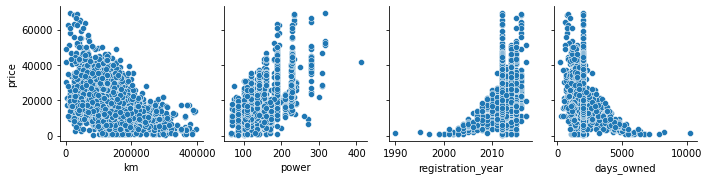

In [69]:
# Scatter: numeric variables vs. target
sns.pairplot(df_bmw, x_vars=numeric_vars, y_vars=target)
plt.show()

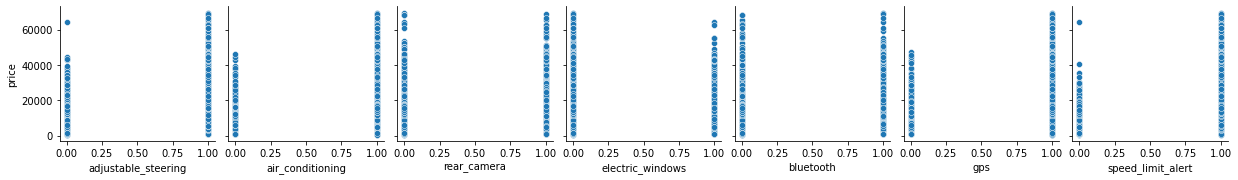

In [70]:
# Scatter: boolean variables vs. target
sns.pairplot(df_bmw, x_vars=boolean_vars, y_vars=target)
plt.show()

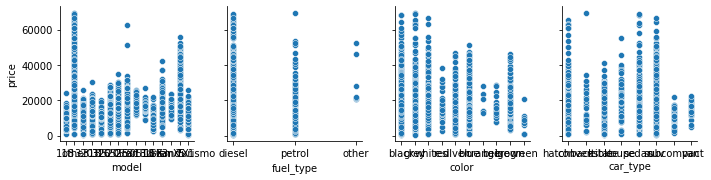

In [71]:
# Scatter: categorical variables vs. target
sns.pairplot(df_bmw, x_vars=categorical_vars, y_vars=target)
plt.show()

### 5. Correlation: Detecting if there are variables that explains the same

We inspect the correlation matrix to detect variables that encode the same information. `days_owned` is highly correlated with `registration_year`, so we keep only one of the two to avoid redundancy.

In [72]:
corr = df_bmw.corr(numeric_only=True)

In [73]:
corr.style.background_gradient(cmap='coolwarm')

,km,power,adjustable_steering,air_conditioning,rear_camera,electric_windows,bluetooth,gps,speed_limit_alert,price,registration_year,days_owned
km,1.000000,-0.035587,0.076152,0.029658,0.004839,0.054192,-0.030590,0.159420,-0.014264,-0.424707,-0.335311,0.339192
power,-0.035587,1.000000,0.325801,0.180333,0.312753,0.346142,0.205841,0.009219,0.509662,0.675894,0.052729,-0.055453
adjustable_steering,0.076152,0.325801,1.000000,0.285138,0.254633,0.277766,0.124151,0.243661,0.243743,0.283077,-0.047897,0.054401
air_conditioning,0.029658,0.180333,0.285138,1.000000,0.144797,0.258435,0.101081,0.345134,0.203224,0.241904,0.137631,-0.135861
rear_camera,0.004839,0.312753,0.254633,0.144797,1.000000,0.198923,0.125960,0.061056,0.196341,0.264961,-0.022793,0.022772
electric_windows,0.054192,0.346142,0.277766,0.258435,0.198923,1.000000,0.231698,0.200371,0.339471,0.286749,0.057913,-0.061302
bluetooth,-0.030590,0.205841,0.124151,0.101081,0.125960,0.231698,1.000000,0.115465,0.095014,0.203990,0.045506,-0.047696
gps,0.159420,0.009219,0.243661,0.345134,0.061056,0.200371,0.115465,1.000000,-0.050477,0.013270,-0.045503,0.053659
speed_limit_alert,-0.014264,0.509662,0.243743,0.203224,0.196341,0.339471,0.095014,-0.050477,1.000000,0.458592,0.090244,-0.090647
price,-0.424707,0.675894,0.283077,0.241904,0.264961,0.286749,0.203990,0.013270,0.458592,1.000000,0.328756,-0.328890


In [74]:
# Drop 'days_owned' (highly correlated with registration_year)
del df_bmw['days_owned']

In [75]:
df_bmw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4788 entries, 0 to 4842
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model                4788 non-null   object 
 1   km                   4788 non-null   float64
 2   power                4788 non-null   float64
 3   fuel_type            4788 non-null   object 
 4   color                4788 non-null   object 
 5   car_type             4788 non-null   object 
 6   adjustable_steering  4788 non-null   int64  
 7   air_conditioning     4788 non-null   int64  
 8   rear_camera          4788 non-null   int64  
 9   electric_windows     4788 non-null   int64  
 10  bluetooth            4788 non-null   int64  
 11  gps                  4788 non-null   int64  
 12  speed_limit_alert    4788 non-null   int64  
 13  price                4788 non-null   float64
 14  registration_year    4788 non-null   int64  
dtypes: float64(3), int64(8), object(4)
memory u

### Table normalization

In [76]:
numeric_vars, boolean_vars, categorical_vars = get_variable_lists(df_bmw)

In [77]:
categorical_vars

['model', 'fuel_type', 'color', 'car_type']

Now we make the table model-ready: one-hot encode the categorical variables, convert the booleans to 0/1, and min-max scale the numeric features so they all share a comparable 0-1 range.

In [78]:
df_bmw = pd.get_dummies(data=df_bmw, columns=categorical_vars)

In [79]:
df_bmw.head()

,km,power,adjustable_steering,air_conditioning,rear_camera,electric_windows,bluetooth,gps,speed_limit_alert,price,...,color_silver,color_white,car_type_convertible,car_type_coupe,car_type_estate,car_type_hatchback,car_type_sedan,car_type_subcompact,car_type_suv,car_type_van
0,140411.0,100.0,1,1,0,1,0,1,0,11300.0,...,False,False,False,False,False,True,False,False,False,False
1,13929.0,317.0,1,1,0,0,1,1,1,69700.0,...,False,False,True,False,False,False,False,False,False,False
2,183297.0,120.0,0,0,0,1,0,1,0,10200.0,...,False,True,False,False,True,False,False,False,False,False
3,128035.0,135.0,1,1,0,1,1,1,1,25100.0,...,False,False,True,False,False,False,False,False,False,False
4,97097.0,160.0,1,1,0,0,1,1,1,33400.0,...,True,False,False,False,False,True,False,False,False,False


In [80]:
df_bmw.shape

(4788, 47)

In [81]:
# Helper to collect boolean columns (the dummy columns are of bool dtype)
def get_bool_columns(df):
    bool_columns = df.select_dtypes(include=['bool']).columns.tolist()
    return bool_columns

In [82]:
boolean_vars = get_bool_columns(df_bmw)

In [83]:
df_bmw = bool_to_int(df_bmw, boolean_vars)

In [84]:
df_bmw.head()

,km,power,adjustable_steering,air_conditioning,rear_camera,electric_windows,bluetooth,gps,speed_limit_alert,price,...,color_silver,color_white,car_type_convertible,car_type_coupe,car_type_estate,car_type_hatchback,car_type_sedan,car_type_subcompact,car_type_suv,car_type_van
0,140411.0,100.0,1,1,0,1,0,1,0,11300.0,...,0,0,0,0,0,1,0,0,0,0
1,13929.0,317.0,1,1,0,0,1,1,1,69700.0,...,0,0,1,0,0,0,0,0,0,0
2,183297.0,120.0,0,0,0,1,0,1,0,10200.0,...,0,1,0,0,1,0,0,0,0,0
3,128035.0,135.0,1,1,0,1,1,1,1,25100.0,...,0,0,1,0,0,0,0,0,0,0
4,97097.0,160.0,1,1,0,0,1,1,1,33400.0,...,1,0,0,0,0,1,0,0,0,0


In [85]:
numeric_vars

['km', 'power', 'registration_year']

In [86]:
min_max_scaler = MinMaxScaler()
for col in numeric_vars:
    df_bmw[col] = min_max_scaler.fit_transform(df_bmw[col].values.reshape(-1, 1))

In [87]:
df_bmw.reset_index(drop=True, inplace=True)

In [88]:
target = 'price'
features = df_bmw.columns[df_bmw.columns != target]

# Split the dataset into feature matrix (X) and output (y)
X = df_bmw[features]
y = df_bmw[target]

Beyond the visual correlation check, we programmatically flag feature pairs correlated above 0.9 and drop the one less related to the target — here, a redundant fuel-type dummy.

In [89]:
# Detect highly correlated feature pairs and flag the one to drop
def highly_correlated(X, y, threshold):
    col_corr = list()  # correlation values of the flagged pairs
    colnames = list()
    rownames = list()
    corr_matrix = X.corr().abs()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if (corr_matrix.iloc[i, j] >= threshold) and (corr_matrix.columns[j] not in col_corr):
                colnames.append(corr_matrix.columns[i])  # column name
                rownames.append(corr_matrix.index[j])
                col_corr.append(corr_matrix.iloc[i, j])
    Z = pd.DataFrame({'F1': colnames,
                      'F2': rownames,
                      'corr_F1_F2': col_corr,
                      'corr_F1_target': [np.abs(np.corrcoef(X[i], y)[0, 1]) for i in colnames],
                      'corr_F2_target': [np.abs(np.corrcoef(X[i], y)[0, 1]) for i in rownames]
                      })
    Z['F_to_delete'] = rownames
    Z['F_to_delete'][Z['corr_F1_target'] < Z['corr_F2_target']] = Z['F1'][Z['corr_F1_target'] < Z['corr_F2_target']]

    return Z

highly_corr = highly_correlated(X, y, 0.9)
highly_corr

C:\TEMP/ipykernel_16056/1886205190.py:20: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  Z['F_to_delete'][Z['corr_F1_target'] < Z['corr_F2_target']] = Z['F1'][Z['corr_F1_target'] < Z['corr_F2_target']]
C:\TEMP/ipykernel_16056/1886205190.py:20

,F1,F2,corr_F1_F2,corr_F1_target,corr_F2_target,F_to_delete
0,fuel_type_petrol,fuel_type_diesel,0.978421,0.03626,0.022323,fuel_type_diesel


In [90]:
del df_bmw['fuel_type_diesel']

### Low Variance Columns

In [91]:
target = 'price'
features = df_bmw.columns[df_bmw.columns != target]

# Split the dataset into feature matrix (X) and output (y)
X = df_bmw[features]
y = df_bmw[target]

As a final step, we remove near-constant one-hot columns (where ~99% of the values are identical), since they carry almost no signal, and export the finished, model-ready dataset.

In [92]:
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.01)  # Drop columns where 99% of the values are equal
vt.fit(X)

cols_lowvar = X.columns[vt.get_support() == False]
print(len(cols_lowvar), ' low variance features will be removed:\n', cols_lowvar.to_list())

X = X.drop(columns=cols_lowvar)
X.shape

8  low variance features will be removed:
 ['registration_year', 'fuel_type_other', 'color_beige', 'color_green', 'color_orange', 'color_red', 'car_type_convertible', 'car_type_van']


(4788, 37)

In [93]:
df_bmw = X.copy()

In [94]:
df_bmw.head()

,km,power,adjustable_steering,air_conditioning,rear_camera,electric_windows,bluetooth,gps,speed_limit_alert,model_116,...,color_brown,color_grey,color_silver,color_white,car_type_coupe,car_type_estate,car_type_hatchback,car_type_sedan,car_type_subcompact,car_type_suv
0,0.351978,0.098266,1,1,0,1,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
1,0.033838,0.725434,1,1,0,0,1,1,1,0,...,0,1,0,0,0,0,0,0,0,0
2,0.459850,0.156069,0,0,0,1,0,1,0,0,...,0,0,0,1,0,1,0,0,0,0
3,0.320849,0.199422,1,1,0,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0.243031,0.271676,1,1,0,0,1,1,1,0,...,0,0,1,0,0,0,1,0,0,0


In [95]:
df_bmw.shape

(4788, 37)

In [96]:
df_bmw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4788 entries, 0 to 4787
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   km                      4788 non-null   float64
 1   power                   4788 non-null   float64
 2   adjustable_steering     4788 non-null   int64  
 3   air_conditioning        4788 non-null   int64  
 4   rear_camera             4788 non-null   int64  
 5   electric_windows        4788 non-null   int64  
 6   bluetooth               4788 non-null   int64  
 7   gps                     4788 non-null   int64  
 8   speed_limit_alert       4788 non-null   int64  
 9   model_116               4788 non-null   int64  
 10  model_118               4788 non-null   int64  
 11  model_316               4788 non-null   int64  
 12  model_318               4788 non-null   int64  
 13  model_318 Gran Turismo  4788 non-null   int64  
 14  model_320               4788 non-null   

In [97]:
# Export the cleaned, model-ready dataset
import os
os.makedirs('data', exist_ok=True)  # crea la carpeta si no existe

df_bmw.to_csv('data/bmw_pricing_clean.csv', index=False)
print('Clean dataset saved with shape:', df_bmw.shape)

Clean dataset saved with shape: (4788, 37)
